<a href="https://colab.research.google.com/github/vu1f2425010-cpu/yuva-/blob/main/week_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

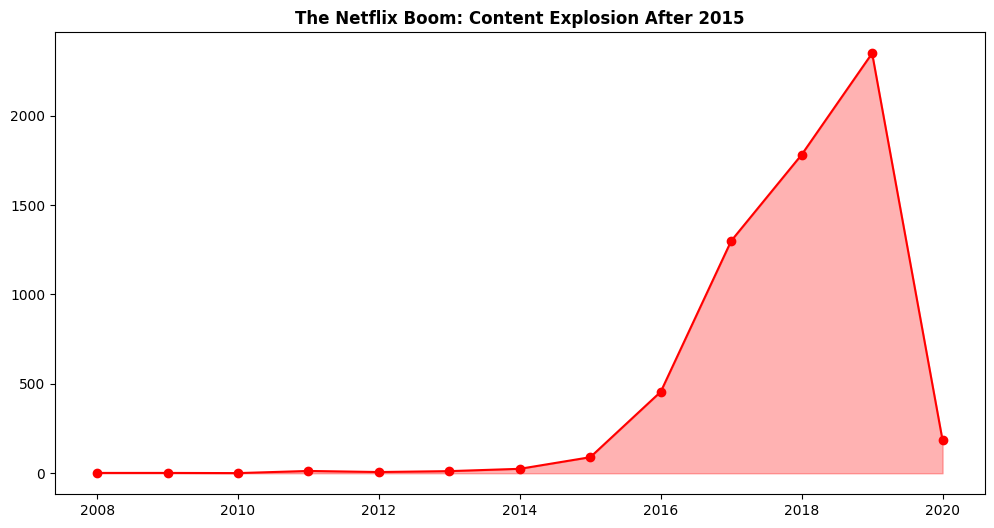

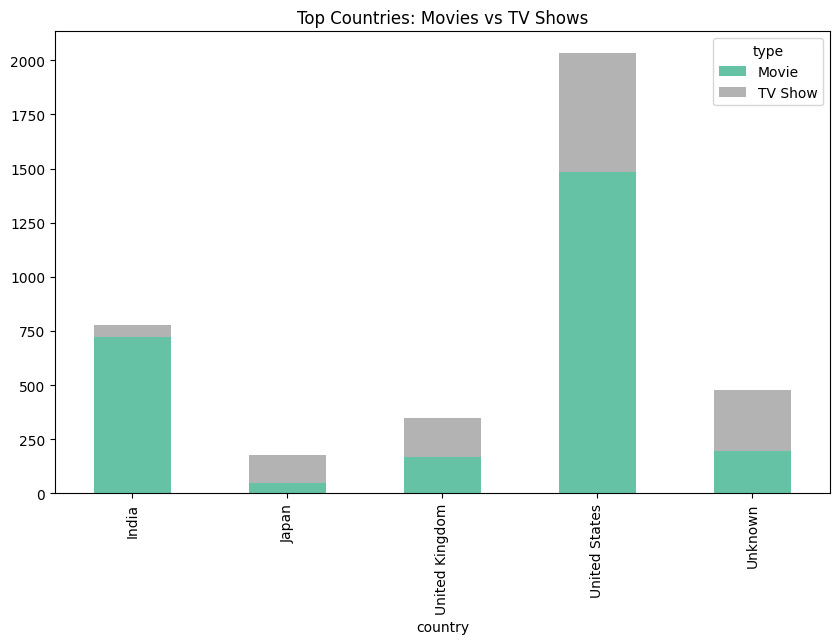

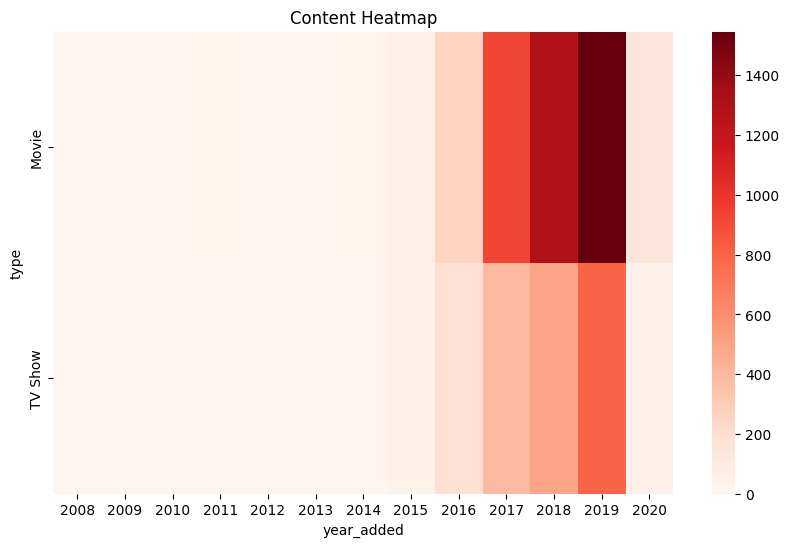

/tmp/ipykernel_472/2623478056.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




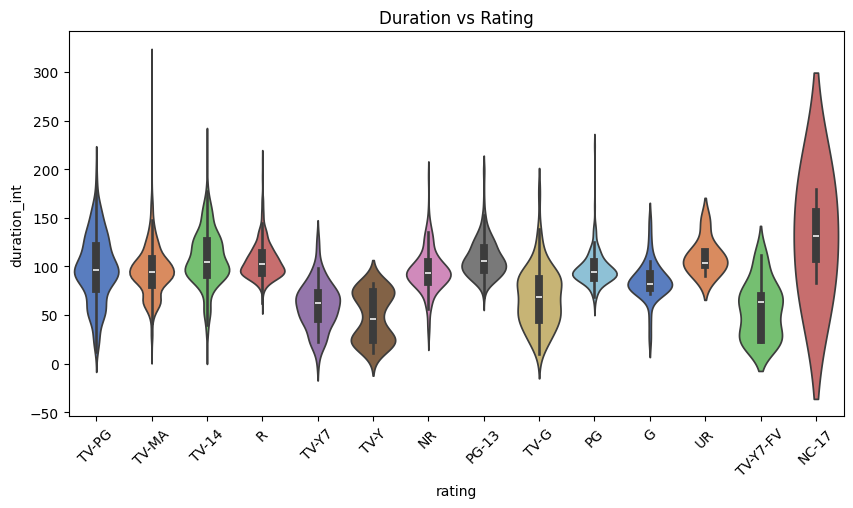

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

url = 'https://raw.githubusercontent.com/Sharath432/EDA-NETFLIX-/main/netflix_titles.csv'
df = pd.read_csv(url)

# Cleaning
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['date_added'] = df['date_added'].fillna('Unknown')
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

# --- FIX IS HERE ---
df_clean = df[df['date_added']!='Unknown'].copy()
df_clean['date_added'] = pd.to_datetime(df_clean['date_added'].str.strip(), format='mixed')
df_clean['year_added'] = df_clean['date_added'].dt.year

# 1. Boom Chart
plt.figure(figsize=(12,6))
yearly = df_clean['year_added'].value_counts().sort_index()
plt.fill_between(yearly.index, yearly.values, color='red', alpha=0.3)
plt.plot(yearly.index, yearly.values, color='red', marker='o')
plt.title('The Netflix Boom: Content Explosion After 2015', fontweight='bold')
plt.show()

# 2. Country vs Type
top5 = df['country'].value_counts().head(5).index
pd.crosstab(df[df['country'].isin(top5)]['country'], df[df['country'].isin(top5)]['type']).plot(kind='bar', stacked=True, figsize=(10,6), colormap='Set2')
plt.title('Top Countries: Movies vs TV Shows')
plt.show()

# 3. Rating
fig = px.pie(values=df['rating'].value_counts().head(8).values, names=df['rating'].value_counts().head(8).index, hole=0.5, title='Target Audience')
fig.show()

# 4. Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(pd.crosstab(df_clean['year_added'], df_clean['type']).T, cmap='Reds')
plt.title('Content Heatmap')
plt.show()

# 5. Duration
df_movie = df[df['type']=='Movie'].copy()
df_movie['duration_int'] = df_movie['duration'].str.replace(' min','').astype(int)
plt.figure(figsize=(10,5))
sns.violinplot(data=df_movie, x='rating', y='duration_int', palette='muted')
plt.title('Duration vs Rating')
plt.xticks(rotation=45)
plt.show()
